#name: Maiju Varghese
#roll no: 40
#class: SE AIML
#Expt.-6: Classification of Credit Card Default Risk using Support Vector Machine

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score , confusion_matrix , precision_score , recall_score , f1_score
from sklearn.svm import SVC

In [21]:
data = pd.read_csv("credit.csv",skiprows=1)
data = data.sample(5000,random_state=42)
print(data.columns)
data.drop(columns=["ID"] , inplace = True)
print(data.columns)

Index(['ID', 'LIMIT_BAL', 'GENDER', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0',
       'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
       'default payment next month'],
      dtype='object')
Index(['LIMIT_BAL', 'GENDER', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2',
       'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
       'default payment next month'],
      dtype='object')


In [22]:
print(data.shape)

(5000, 24)


In [23]:
print("\nDataset Info:")
print(data.info())


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
Index: 5000 entries, 2308 to 4110
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   LIMIT_BAL                   5000 non-null   int64
 1   GENDER                      5000 non-null   int64
 2   EDUCATION                   5000 non-null   int64
 3   MARRIAGE                    5000 non-null   int64
 4   AGE                         5000 non-null   int64
 5   PAY_0                       5000 non-null   int64
 6   PAY_2                       5000 non-null   int64
 7   PAY_3                       5000 non-null   int64
 8   PAY_4                       5000 non-null   int64
 9   PAY_5                       5000 non-null   int64
 10  PAY_6                       5000 non-null   int64
 11  BILL_AMT1                   5000 non-null   int64
 12  BILL_AMT2                   5000 non-null   int64
 13  BILL_AMT3                   5000 non-null   int64


In [24]:
print(data.head())

       LIMIT_BAL  GENDER  EDUCATION  MARRIAGE  AGE  PAY_0  PAY_2  PAY_3  \
2308       30000       1          2         2   25      0      0      0   
22404     150000       2          1         2   26      0      0      0   
23397      70000       2          3         1   32      0      0      0   
25058     130000       1          3         2   49      0      0      0   
2664       50000       2          2         2   36      0      0      0   

       PAY_4  PAY_5  ...  BILL_AMT4  BILL_AMT5  BILL_AMT6  PAY_AMT1  PAY_AMT2  \
2308       0      0  ...      12580      13716      14828      1500      2000   
22404      0      0  ...     101581      77741      77264      4486      4235   
23397      0      0  ...      69753      70111      70212      2431      3112   
25058      0      0  ...      16898      11236       6944      1610      1808   
2664       0      0  ...      19574      20295      19439      2000      1500   

       PAY_AMT3  PAY_AMT4  PAY_AMT5  PAY_AMT6  default payment

In [25]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5000 entries, 2308 to 4110
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   LIMIT_BAL                   5000 non-null   int64
 1   GENDER                      5000 non-null   int64
 2   EDUCATION                   5000 non-null   int64
 3   MARRIAGE                    5000 non-null   int64
 4   AGE                         5000 non-null   int64
 5   PAY_0                       5000 non-null   int64
 6   PAY_2                       5000 non-null   int64
 7   PAY_3                       5000 non-null   int64
 8   PAY_4                       5000 non-null   int64
 9   PAY_5                       5000 non-null   int64
 10  PAY_6                       5000 non-null   int64
 11  BILL_AMT1                   5000 non-null   int64
 12  BILL_AMT2                   5000 non-null   int64
 13  BILL_AMT3                   5000 non-null   int64
 14  BILL_AMT4 

In [27]:
y = data['default payment next month']
x = data[['BILL_AMT1','BILL_AMT2']]
print(x.dtypes)
print(x.head())

BILL_AMT1    int64
BILL_AMT2    int64
dtype: object
       BILL_AMT1  BILL_AMT2
2308        8864      10062
22404     136736     125651
23397      70122      69080
25058      20678      18956
2664       94228      47635


In [28]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3,random_state=42)

In [29]:
scaler = StandardScaler()
x_train= scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [30]:
models={
    " Linear SVM " : SVC( kernel = 'linear',
                        C=1 ,
                        class_weight='balanced'),

    " Polynomial SVM " : SVC ( kernel = 'poly',
                              degree = 2,
                              C=1,
                              gamma = 'scale',
                              class_weight = 'balanced'),

    " RBF SVM " : SVC ( kernel = 'rbf',
                    C=5,
                    gamma=0.1,
                    class_weight='balanced')
}

In [31]:
for name , model in models.items():
    model.fit(x_train , y_train)
    y_pred=model.predict(x_test)

    print("\n",name)
    print("Confusion Matrix:\n",confusion_matrix(y_test,y_pred))
    print("\nPrecision:",precision_score(y_test,y_pred , zero_division=0))
    print("\nRecall:",recall_score(y_test,y_pred))
    print("\nF1 Score:",f1_score(y_test, y_pred))
    print("\nAccuracy Score :",accuracy_score(y_test, y_pred))


  Linear SVM 
Confusion Matrix:
 [[ 103 1056]
 [  34  307]]

Precision: 0.2252384446074835

Recall: 0.9002932551319648

F1 Score: 0.36032863849765256

Accuracy Score : 0.2733333333333333

  Polynomial SVM 
Confusion Matrix:
 [[  35 1124]
 [   8  333]]

Precision: 0.22855181880576528

Recall: 0.9765395894428153

F1 Score: 0.3704115684093437

Accuracy Score : 0.24533333333333332

  RBF SVM 
Confusion Matrix:
 [[560 599]
 [166 175]]

Precision: 0.22609819121447028

Recall: 0.5131964809384164

F1 Score: 0.31390134529147984

Accuracy Score : 0.49


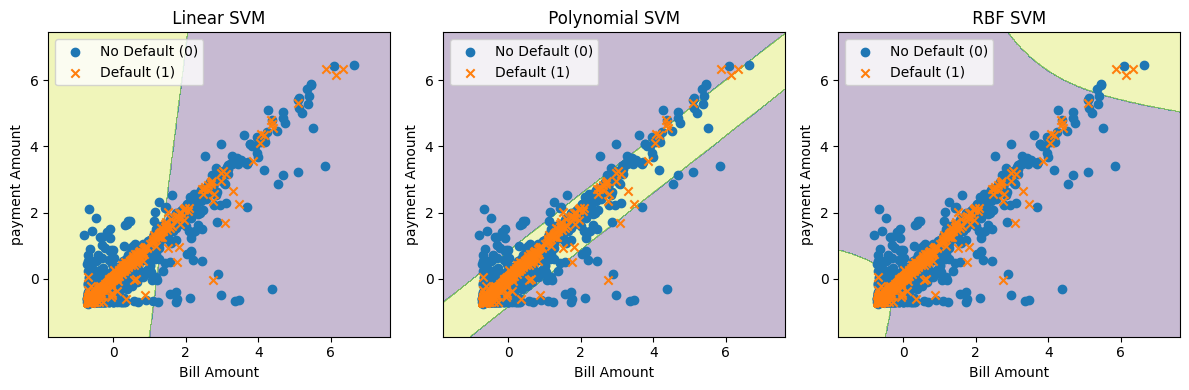

In [32]:
def plot_boundary(model,title):
    h=0.02
    x_min , x_max = x_train[:,0].min()-1,x_train[:,0].max()+1
    y_min , y_max= x_train[:,1].min()-1,x_train[:,1].max()+1
    xx ,yy = np.meshgrid(
        np.arange(x_min ,x_max ,h),
        np.arange(y_min ,y_max ,h)
    )

    Z=model.predict(np.c_[xx.ravel(),yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx,yy,Z,alpha=0.3)

    plt.scatter(x_train[y_train==0,0],
               x_train[y_train==0,1],
               label='No Default (0)',
               marker='o')

    #Class 1
    plt.scatter(x_train[y_train==1,0],
               x_train[y_train==1,1],
               label='Default (1)',
               marker='x')

    plt.legend()
    plt.title(title)
    plt.xlabel("Bill Amount")
    plt.ylabel("payment Amount")

plt.figure(figsize=(12,4))

for i ,(name,model)in enumerate (models.items()):
    plt.subplot(1,3,i+1)
    model.fit(x_train,y_train)
    plot_boundary(model,name)

plt.tight_layout()
plt.show()